# Lesson 9: Segmentation


- Here is some code that suppresses warning messages.

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

### Mask Generation with SAM

The [Segment Anything Model (SAM)](https://segment-anything.com) model was released by Meta AI.

In [2]:
from transformers import pipeline

In [3]:
import os
from pathlib import Path


data_dir =  Path(os.getcwd()).parent/"data"
hf_model_dir = Path("D:/LocalLLama/hf_models")

In [4]:
sam_pipe = pipeline("mask-generation",
                    model = "Zigeng/SlimSAM-uniform-77",
                    model_kwargs={"cache_dir": str(hf_model_dir)}
                    )

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Info about [Zigeng/SlimSAM-uniform-77](https://huggingface.co/Zigeng/SlimSAM-uniform-77)

In [5]:
from PIL import Image

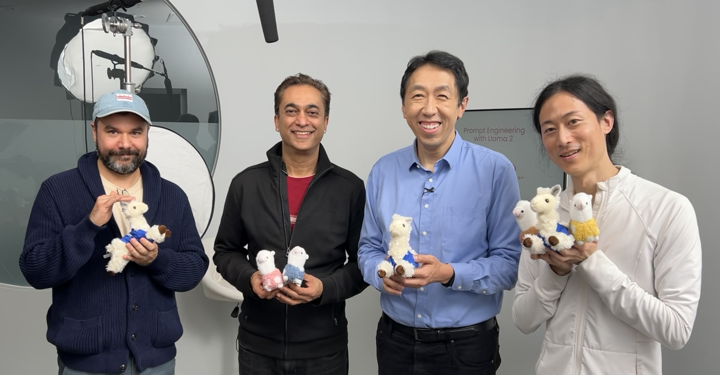

In [6]:
raw_image = Image.open(data_dir/'meta_llamas.jpg')
raw_image.resize((720, 375))

- Running this will take some time
- The higher the value of 'points_per_batch', the more efficient pipeline inference will be

In [7]:
output = sam_pipe(raw_image, points_per_batch=16)

In [8]:
from helper import show_pipe_masks_on_image

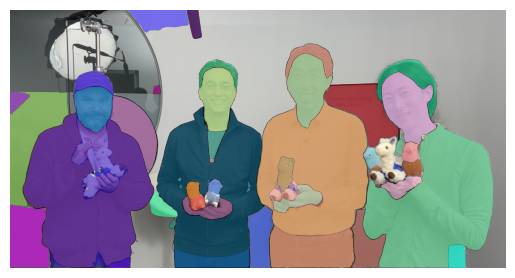

In [9]:
show_pipe_masks_on_image(raw_image, output)

_Note:_ The colors of segmentation, that you will get when running this code, might be different than the ones you see in the video.

### Faster Inference: Infer an Image and a Single Point

In [10]:
from transformers import SamModel, SamProcessor

In [12]:
model = SamModel.from_pretrained(
    "Zigeng/SlimSAM-uniform-77", cache_dir=hf_model_dir)

processor = SamProcessor.from_pretrained(
    "Zigeng/SlimSAM-uniform-77", cache_dir=hf_model_dir)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

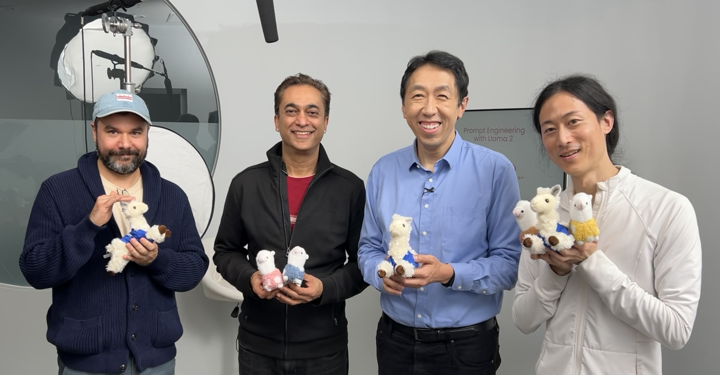

In [13]:
raw_image.resize((720, 375))

- Segment the blue shirt Andrew is wearing.
- Give any single 2D point that would be in that region (blue shirt).

In [14]:
input_points = [[[1600, 700]]]

- Create the input using the image and the single point.
- `return_tensors="pt"` means to return PyTorch Tensors.

In [15]:
inputs = processor(raw_image,
                 input_points=input_points,
                 return_tensors="pt")

- Given the inputs, get the output from the model.

In [16]:
import torch

In [17]:
with torch.no_grad():
    outputs = model(**inputs)

In [18]:
predicted_masks = processor.image_processor.post_process_masks(
    outputs.pred_masks,
    inputs["original_sizes"],
    inputs["reshaped_input_sizes"]
)

 Length of `predicted_masks` corresponds to the number of images that are used in the input.

In [19]:
len(predicted_masks)

1

- Inspect the size of the first ([0]) predicted mask

In [20]:
predicted_mask = predicted_masks[0]
predicted_mask.shape

torch.Size([1, 3, 1500, 2880])

In [21]:
outputs.iou_scores

tensor([[[0.9583, 0.9552, 0.9580]]])

In [22]:
from helper import show_mask_on_image

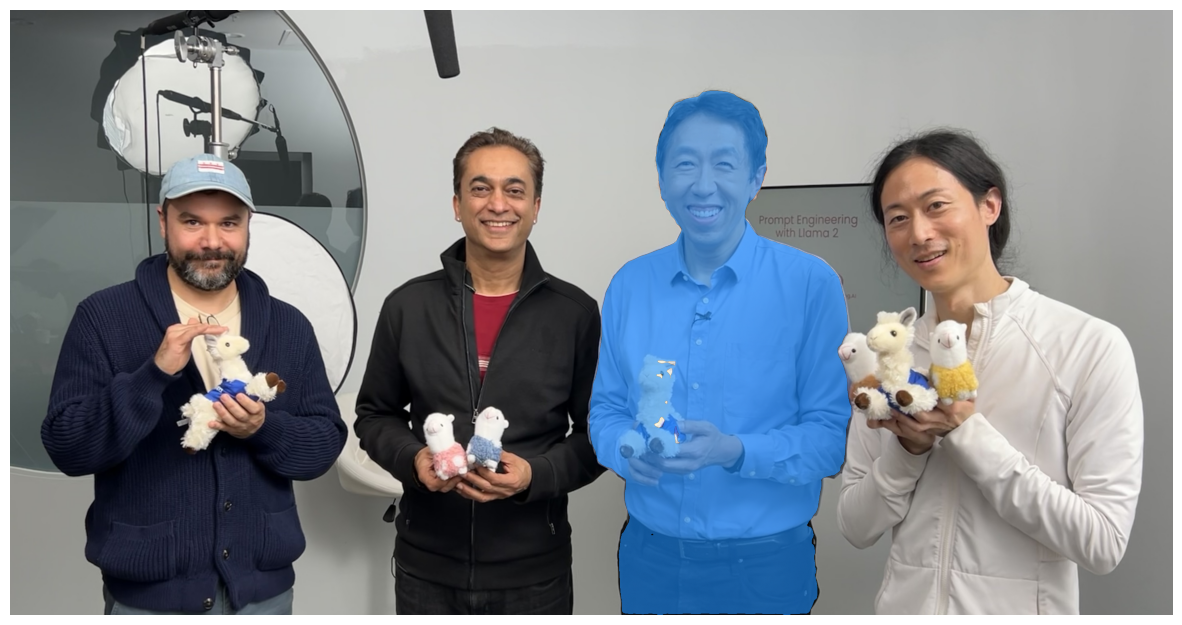

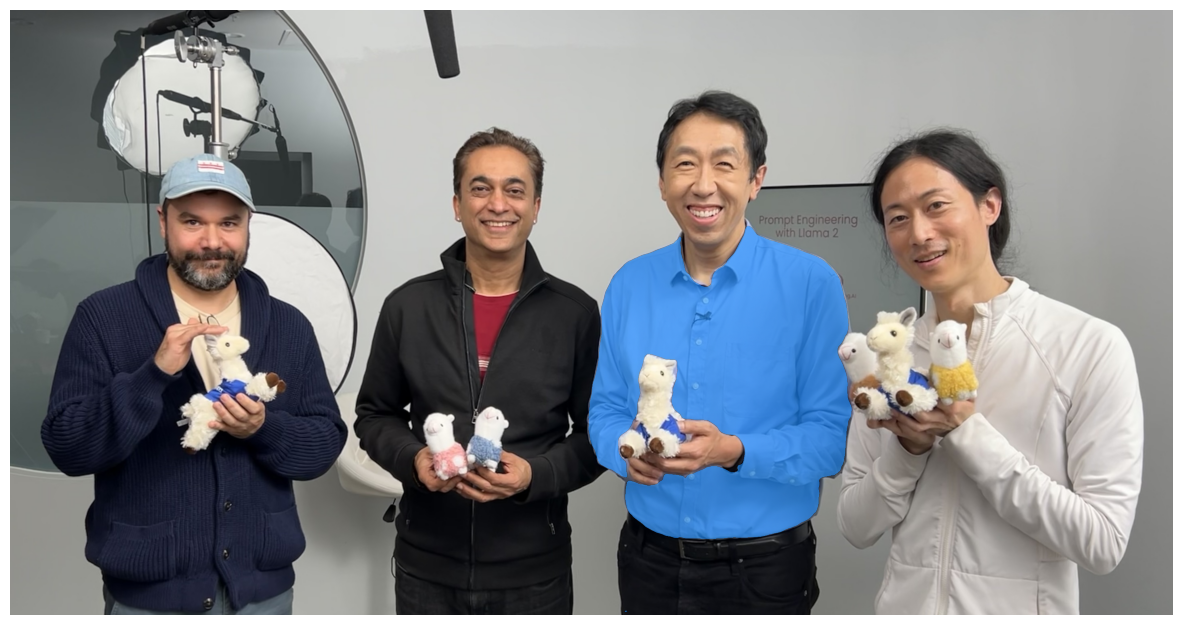

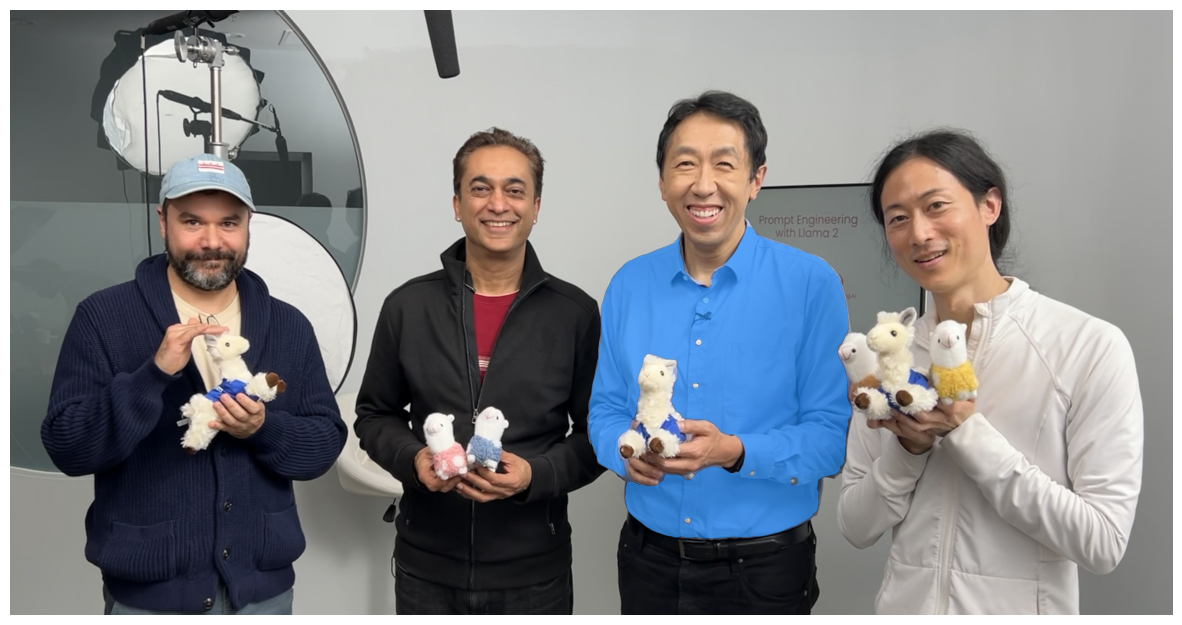

In [23]:
for i in range(3):
    show_mask_on_image(raw_image, predicted_mask[:, i])

## Depth Estimation with DPT

- This model was introduced in the paper [Vision Transformers for Dense Prediction](https://arxiv.org/abs/2103.13413) by Ranftl et al. (2021) and first released in [isl-org/DPT](https://github.com/isl-org/DPT).

In [24]:
depth_estimator = pipeline(task="depth-estimation",
                        model="Intel/dpt-hybrid-midas",
                        model_kwargs={"cache_dir": str(hf_model_dir)}
                        )

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/490M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/490M [00:00<?, ?B/s]

Info about ['Intel/dpt-hybrid-midas'](https://huggingface.co/Intel/dpt-hybrid-midas)

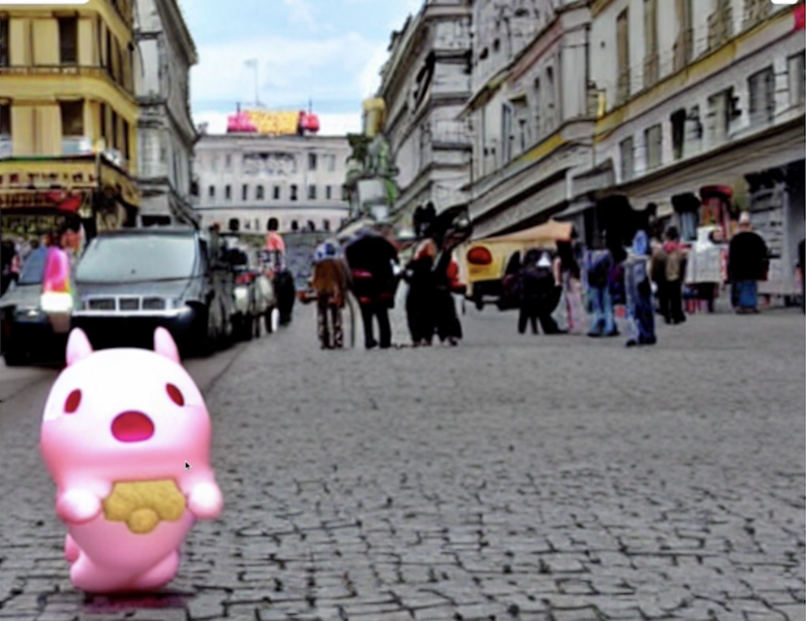

In [25]:
raw_image = Image.open(data_dir/'gradio_tamagochi_vienna.png')
raw_image.resize((806, 621))

- If you'd like to generate this image or something like it, check out the short course on [Gradio](https://www.deeplearning.ai/short-courses/building-generative-ai-applications-with-gradio/) and go to the lesson "Image Generation App".

In [26]:
output = depth_estimator(raw_image)

In [27]:
output

{'predicted_depth': tensor([[ 248.2937,  248.3973,  248.8936,  ...,  468.0062,  446.9488,
           442.8007],
         [ 248.1672,  248.2807,  248.8282,  ...,  477.7057,  458.3388,
           454.5231],
         [ 247.2202,  247.3753,  248.1362,  ...,  508.7981,  494.8960,
           492.1544],
         ...,
         [3040.0625, 3040.4216, 3042.2527,  ..., 3286.0793, 3284.1040,
          3283.7151],
         [3037.8557, 3038.3711, 3041.0103,  ..., 3289.0405, 3287.3149,
          3286.9700],
         [3037.5234, 3038.0850, 3040.9644,  ..., 3290.0566, 3288.3799,
          3288.0430]]),
 'depth': <PIL.Image.Image image mode=L size=1612x1242>}

- Post-process the output image to resize it to the size of the original image.

In [28]:
output["predicted_depth"].shape

torch.Size([1242, 1612])

In [33]:
output["predicted_depth"].unsqueeze(0).unsqueeze(0).shape

torch.Size([1, 1, 1242, 1612])

In [34]:
prediction = torch.nn.functional.interpolate(
    output["predicted_depth"].unsqueeze(0).unsqueeze(0),
    size=raw_image.size[::-1],
    mode="bicubic",
    align_corners=False,
)

In [35]:
prediction.shape

torch.Size([1, 1, 1242, 1612])

In [36]:
raw_image.size[::-1],

((1242, 1612),)

In [37]:
prediction

tensor([[[[ 248.2937,  248.3973,  248.8936,  ...,  468.0062,  446.9488,
            442.8007],
          [ 248.1672,  248.2807,  248.8282,  ...,  477.7057,  458.3388,
            454.5231],
          [ 247.2202,  247.3753,  248.1362,  ...,  508.7981,  494.8960,
            492.1544],
          ...,
          [3040.0625, 3040.4216, 3042.2527,  ..., 3286.0793, 3284.1040,
           3283.7151],
          [3037.8557, 3038.3711, 3041.0103,  ..., 3289.0405, 3287.3149,
           3286.9700],
          [3037.5234, 3038.0850, 3040.9644,  ..., 3290.0566, 3288.3799,
           3288.0430]]]])

- Normalize the predicted tensors (between 0 and 255) so that they can be displayed.

In [38]:
import numpy as np

In [39]:
output = prediction.squeeze().numpy()
formatted = (output * 255 / np.max(output)).astype("uint8")
depth = Image.fromarray(formatted)

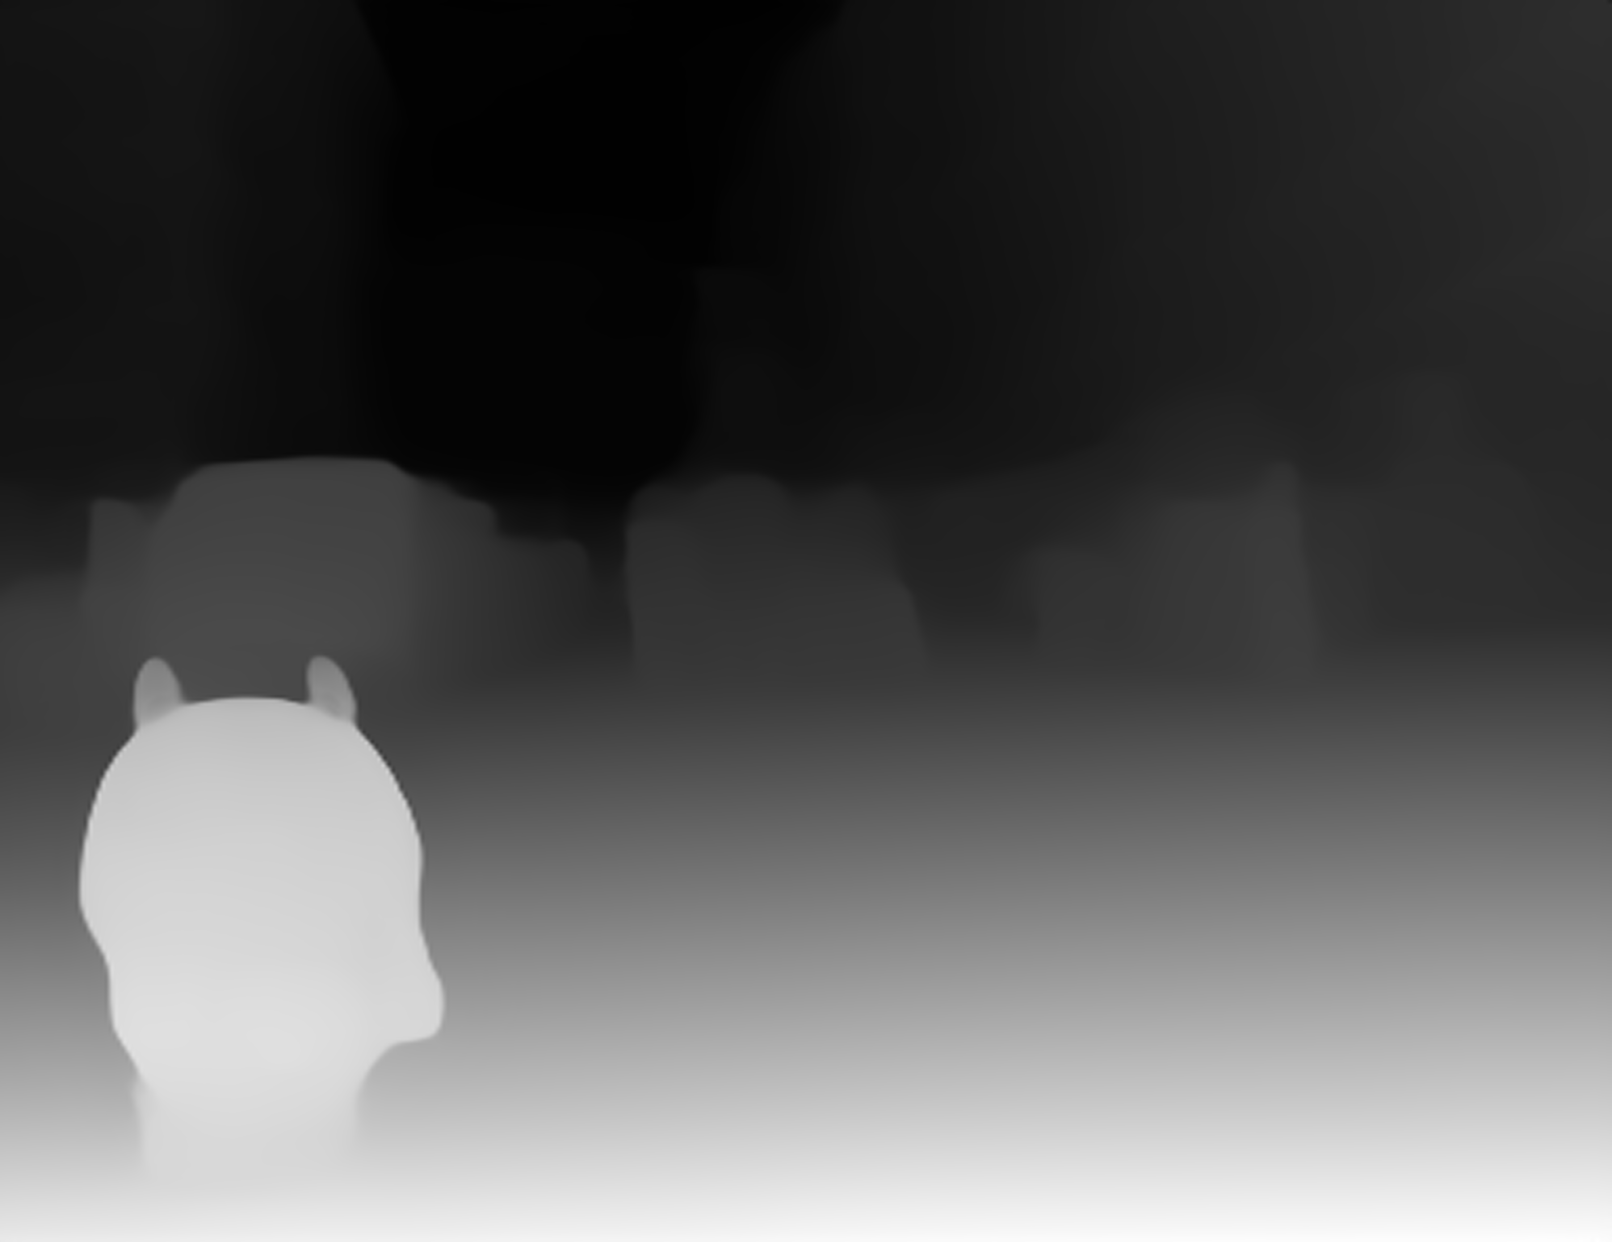

In [40]:
depth

### Demo using Gradio

### Troubleshooting Tip
- Note, in the classroom, you may see the code for creating the Gradio app run indefinitely.
  - This is specific to this classroom environment when it's serving many learners at once, and you won't wouldn't experience this issue if you run this code on your own machine.
- To fix this, please restart the kernel (Menu Kernel->Restart Kernel) and re-run the code in the lab from the beginning of the lesson.

In [ ]:
import os
import gradio as gr
from transformers import pipeline

In [ ]:
def launch(input_image):
    out = depth_estimator(input_image)

    # resize the prediction
    prediction = torch.nn.functional.interpolate(
        out["predicted_depth"].unsqueeze(1),
        size=input_image.size[::-1],
        mode="bicubic",
        align_corners=False,
    )

    # normalize the prediction
    output = prediction.squeeze().numpy()
    formatted = (output * 255 / np.max(output)).astype("uint8")
    depth = Image.fromarray(formatted)
    return depth

In [ ]:
iface = gr.Interface(launch,
                     inputs=gr.Image(type='pil'),
                     outputs=gr.Image(type='pil'))

In [ ]:
iface.launch(share=True, server_port=int(os.environ['PORT1']))

In [ ]:
iface.close()

### Close the app
- Remember to call `.close()` on the Gradio app when you're done using it.

### Try it yourself! 
- Try this model with your own images!